# Mapper: the topological skeleton of a dataset

Labels tell you *which* cluster a point is in. **Mapper** tells you the *shape* of the data — the
loops, branches, and the thin **bridges** where two otherwise-separate regions touch (in an
embedding store, exactly the "topic leakage" you want to find and cut). A centroid model cannot see
a hole or a bridge; Mapper can.

`betula-cluster` runs [TDA Mapper](https://research.math.osu.edu/tgda/mapperPBG.pdf) over the
**microclusters** the CF-tree already built (`M ≪ N`), so it is cheap. A *lens* (here the x
coordinate) is covered by overlapping bins; microclusters in each bin are single-linked at a
data-adaptive scale (`link_scale ×` the bin's median nearest-neighbour gap); one graph node per
(bin, component); nodes that share a microcluster are linked. `Betula.mapper()` returns a
`MapperGraph` with `nodes`, weighted `edges`, `branch_points` (degree ≥ 3) and `bridges` (edges
whose removal disconnects the graph).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import betula_cluster


def ring(center, radius, n, thickness, rng):
    """`n` noisy points on a circle — an annulus with a genuine hole in the middle."""
    theta = rng.uniform(0, 2 * np.pi, n)
    rad = radius + rng.normal(0, thickness, n)
    return np.c_[center[0] + rad * np.cos(theta), center[1] + rad * np.sin(theta)]


def plot_mapper(ax, points, mg, title):
    """Overlay a MapperGraph on its data: nodes at member centroids (size ∝ mass, colour = lens),
    nerve edges in blue, detected bridges in red, branch points ringed in orange."""
    ax.scatter(points[:, 0], points[:, 1], s=5, c="0.8", alpha=0.6, zorder=1)
    pos = mg.node_centroids
    bridges = set(mg.bridges.tolist())
    for e, (a, b, _w) in enumerate(mg.edges):
        red = e in bridges
        ax.plot(
            [pos[a, 0], pos[b, 0]],
            [pos[a, 1], pos[b, 1]],
            c="crimson" if red else "steelblue",
            lw=3.0 if red else 1.4,
            zorder=3 if red else 2,
        )
    sizes = 30 + 220 * mg.node_mass / mg.node_mass.max()
    ax.scatter(
        pos[:, 0], pos[:, 1], s=sizes, c=mg.node_lens, cmap="viridis",
        edgecolors="k", linewidths=0.4, zorder=4,
    )
    if len(mg.branch_points):
        bp = mg.branch_points
        ax.scatter(
            pos[bp, 0], pos[bp, 1], s=sizes[bp] + 160, facecolors="none",
            edgecolors="orange", linewidths=2.2, zorder=5,
        )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axis("off")


rng = np.random.default_rng(0)

## 1. A ring — Mapper recovers the hole as a loop

Cluster a noisy circle and lens it by the x coordinate. Each vertical bin meets the ring in an
**upper** and a **lower** arc — two graph nodes — and the chains rejoin at the left/right extremes,
so the Mapper graph closes into a **cycle**: the loop in the graph *is* the hole in the data. (`edges
≥ nodes` ⇒ a cycle is present; a tree would have `edges = nodes − 1`. A couple of low-mass stray
nodes show up as short red bridges off the loop.)

nodes=20  edges=20  branch_points=2  bridges=2
cycle present (edges >= nodes): True


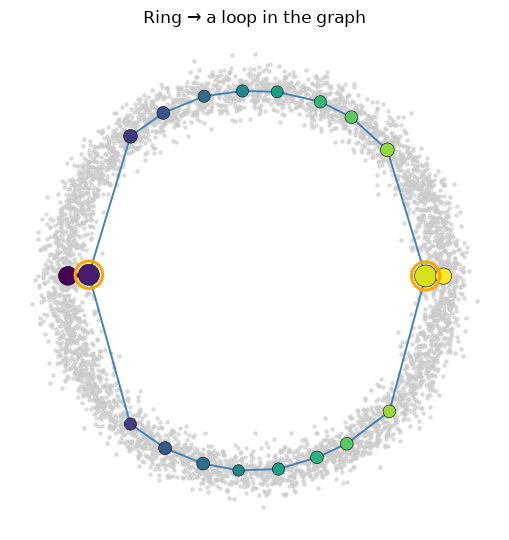

In [2]:
Xr = ring((0, 0), 3.0, 5000, 0.18, rng)
ring_model = betula_cluster.Betula(
    feature="spherical", method="hdbscan", threshold=0.0, max_leaves=220
).fit(Xr)
mg_ring = ring_model.mapper(
    lens="coordinate", coordinate=0, resolution=12, gain=0.4, link_scale=2.5, min_node_mass=20
)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
plot_mapper(ax, Xr, mg_ring, "Ring → a loop in the graph")
print(f"nodes={mg_ring.n_nodes}  edges={mg_ring.n_edges}  "
      f"branch_points={len(mg_ring.branch_points)}  bridges={len(mg_ring.bridges)}")
print(f"cycle present (edges >= nodes): {mg_ring.n_edges >= mg_ring.n_nodes}")
plt.tight_layout()
plt.show()

## 2. Two rings joined by a bridge — the leak is the red edge

Two rings connected by a thin neck of points. Each ring stays a **loop** (its own edges lie on a
cycle, so they are not bridges); the edges whose removal disconnects the graph are the **neck**
ones — highlighted in red, with the attachment nodes (degree ≥ 3) ringed in orange. This is the
signal to audit for duplicated / mislabeled / leaking records between two embedding clusters.

nodes=29  edges=29  branch_points=3  bridges=3


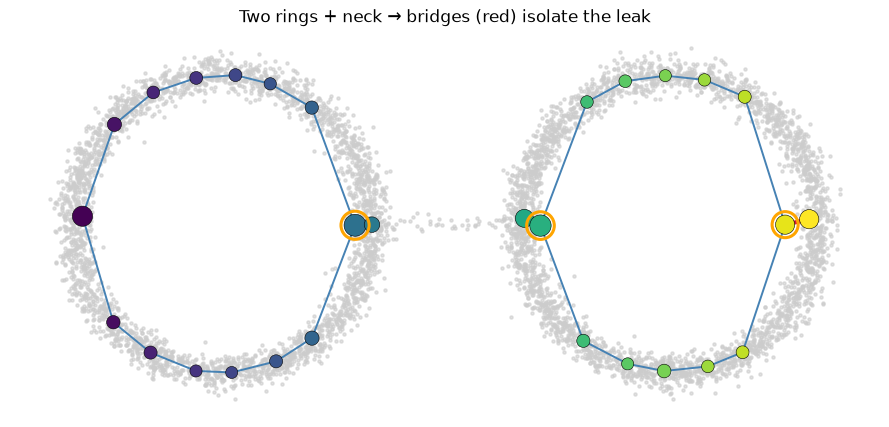

In [3]:
ring_a = ring((0, 0), 3.0, 3000, 0.18, rng)
ring_b = ring((9, 0), 3.0, 3000, 0.18, rng)
neck = np.c_[np.linspace(3.0, 6.0, 50), np.zeros(50)] + rng.normal(0, 0.08, (50, 2))
Xrr = np.vstack([ring_a, neck, ring_b])

two_rings = betula_cluster.Betula(
    feature="spherical", method="hdbscan", threshold=0.0, max_leaves=400
).fit(Xrr)
mg_rr = two_rings.mapper(
    lens="coordinate", coordinate=0, resolution=20, gain=0.4, link_scale=2.5, min_node_mass=20
)

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_mapper(ax, Xrr, mg_rr, "Two rings + neck → bridges (red) isolate the leak")
print(f"nodes={mg_rr.n_nodes}  edges={mg_rr.n_edges}  "
      f"branch_points={len(mg_rr.branch_points)}  bridges={len(mg_rr.bridges)}")
plt.tight_layout()
plt.show()

## 3. Hand the graph to `networkx`

`to_networkx()` returns a `networkx.Graph` (nodes carry `mass` / `bin` / `lens` / `centroid`, edges
carry `weight` and a boolean `bridge`) for any downstream graph analysis — centrality, community
detection, layout, or the connected-component persistence the bridges summarise.

In [4]:
G = mg_rr.to_networkx()
bridge_edges = [(a, b) for a, b, d in G.edges(data=True) if d["bridge"]]
print(f"networkx graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"bridge edges (the neck): {bridge_edges}")
print(f"heaviest node mass: {max(d['mass'] for _, d in G.nodes(data=True)):.0f} points")

networkx graph: 29 nodes, 29 edges
bridge edges (the neck): [(13, 14), (15, 16), (27, 28)]
heaviest node mass: 758 points


### When to reach for it

Mapper is an **exploration** tool, not a partition (use `method="hdbscan"` / `gmm` for labels). It
shines for: auditing embedding stores (bridges = leakage between topics; loops = unexpected
structure), and dedup / curation — all over the microclusters the tree already holds, so it adds no
extra pass over the raw data. Lenses: `density`, `radius`, `l2norm`, `coordinate`, `eccentricity`;
tune the cover with `resolution` × `gain`, connectivity with `link_scale`, and prune specks with
`min_node_mass`.